### Exploratory Data Analysis - Cafe Drink Sales vs. Daily Temperature

#### pandas

In [4]:
import pandas as pd

In [5]:
# 1. Ingestion
df = pd.read_csv("cafe_sales.csv")

# 2. Inspect dimensions
print(f"Dataset Shape: {df.shape} (rows, columns)\n")

# 3. View the first 5 rows
print("--- HEAD ---")
print(df.head())

# 4. Check schema and missing values
print("\n--- INFO ---")
df.info()

# 5. Quick statistical summary of numeric fields
print("\n--- DESCRIBE ---")
print(df.describe())

Dataset Shape: (14, 6) (rows, columns)

--- HEAD ---
         date day_of_week  temp_c  is_weekend  cold_drinks_sold  revenue
0  2024-06-01    Saturday    28.5        True             180.0    990.0
1  2024-06-02      Sunday    31.2        True             225.0   1237.5
2  2024-06-03      Monday    24.0       False             110.0    605.0
3  2024-06-04     Tuesday     NaN       False              95.0    522.5
4  2024-06-05   Wednesday    22.1       False              85.0    467.5

--- INFO ---
<class 'pandas.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   date              14 non-null     str    
 1   day_of_week       14 non-null     str    
 2   temp_c            13 non-null     float64
 3   is_weekend        14 non-null     bool   
 4   cold_drinks_sold  13 non-null     float64
 5   revenue           14 non-null     float64
dtypes: bool(1), float64(3),

In [6]:
# A. Selecting a single column -> Returns a pandas Series
temps = df["temp_c"]

# B. Selecting multiple columns -> Returns a pandas DataFrame
subset = df[["date", "temp_c", "cold_drinks_sold"]]

# C. Integer-based position slicing (.iloc) -> First 3 rows, first 2 columns
first_few = df.iloc[0:3, 0:2]

# D. Label-based selection (.loc) -> Rows 0 to 2 (inclusive), specific column names
labeled_subset = df.loc[0:2, ["date", "revenue"]]

In [7]:
# Condition: Days where temperature was higher than 28°C
hot_days_mask = df["temp_c"] > 28.0

# Apply mask
hot_days = df[hot_days_mask]
print("Hot Days (> 28°C):")
print(hot_days[["date", "temp_c", "cold_drinks_sold"]])

# Multiple conditions using bitwise operators (& for AND, | for OR)
hot_weekends = df[(df["temp_c"] > 28.0) & (df["is_weekend"] == True)]

Hot Days (> 28°C):
          date  temp_c  cold_drinks_sold
0   2024-06-01    28.5             180.0
1   2024-06-02    31.2             225.0
6   2024-06-07    33.0             240.0
7   2024-06-08    35.5             310.0
8   2024-06-09    29.0             205.0
12  2024-06-13    30.1               NaN
13  2024-06-14    32.4             230.0


In [8]:
# Condition: Days where temperature was higher than 28°C
hot_days_mask = df["temp_c"] > 28.0

# Apply mask
hot_days = df[hot_days_mask]
print("Hot Days (> 28°C):")
print(hot_days[["date", "temp_c", "cold_drinks_sold"]])

# Multiple conditions using bitwise operators (& for AND, | for OR)
hot_weekends = df[(df["temp_c"] > 28.0) & (df["is_weekend"] == True)]

Hot Days (> 28°C):
          date  temp_c  cold_drinks_sold
0   2024-06-01    28.5             180.0
1   2024-06-02    31.2             225.0
6   2024-06-07    33.0             240.0
7   2024-06-08    35.5             310.0
8   2024-06-09    29.0             205.0
12  2024-06-13    30.1               NaN
13  2024-06-14    32.4             230.0


In [9]:
# 1. Check for missing values per column
print("Missing values before cleaning:\n", df.isnull().sum())

# 2. Strategy A: Fill missing temperature with the column mean
mean_temp = df["temp_c"].mean()
df["temp_c"] = df["temp_c"].fillna(mean_temp)

# 3. Strategy B: Drop rows where target variable (cold_drinks_sold) is missing
df = df.dropna(subset=["cold_drinks_sold"])

# 4. Convert date column from string/object to proper datetime
df["date"] = pd.to_datetime(df["date"])

print("\nMissing values after cleaning:\n", df.isnull().sum())

Missing values before cleaning:
 date                0
day_of_week         0
temp_c              1
is_weekend          0
cold_drinks_sold    1
revenue             0
dtype: int64

Missing values after cleaning:
 date                0
day_of_week         0
temp_c              0
is_weekend          0
cold_drinks_sold    0
revenue             0
dtype: int64


In [10]:
# Calculate average price per drink sold on that day
df["price_per_drink"] = df["revenue"] / df["cold_drinks_sold"]

# Create a categorization label based on condition
# (e.g., flag peak sales days: cold_drinks_sold > 200)
df["high_volume"] = df["cold_drinks_sold"] > 200

print(df[["date", "cold_drinks_sold", "revenue", "price_per_drink"]].head())

        date  cold_drinks_sold  revenue  price_per_drink
0 2024-06-01             180.0    990.0              5.5
1 2024-06-02             225.0   1237.5              5.5
2 2024-06-03             110.0    605.0              5.5
3 2024-06-04              95.0    522.5              5.5
4 2024-06-05              85.0    467.5              5.5


In [11]:
# Compare average sales on weekends vs. weekdays
weekend_comparison = df.groupby("is_weekend")[
    ["cold_drinks_sold", "revenue"]
].agg(["mean", "std", "count"])

print("Weekend vs Weekday Aggregations:")
print(weekend_comparison)

Weekend vs Weekday Aggregations:
           cold_drinks_sold                       revenue                  
                       mean        std count         mean         std count
is_weekend                                                                 
False            130.555556  65.261227     9   718.055556  358.936750     9
True             230.000000  56.421036     4  1265.000000  310.315699     4


In [12]:
# Extract feature (x) and target (y) as raw NumPy arrays
# .values or .to_numpy() extracts the underlying ndarray
x_temp = df["temp_c"].to_numpy()
y_sales = df["cold_drinks_sold"].to_numpy()

print(f"x_temp type: {type(x_temp)}, shape: {x_temp.shape}")
print(f"y_sales type: {type(y_sales)}, shape: {y_sales.shape}")
print("First 5 temperature values:", x_temp[:5])
print("First 5 drink sales values:", y_sales[:5])

x_temp type: <class 'numpy.ndarray'>, shape: (13,)
y_sales type: <class 'numpy.ndarray'>, shape: (13,)
First 5 temperature values: [28.5        31.2        24.         27.73076923 22.1       ]
First 5 drink sales values: [180. 225. 110.  95.  85.]


#### NumPy

In [13]:
import numpy as np

# Continuing from pandas: x_temp and y_sales are already 1D numpy arrays
print("x_temp dtype:", x_temp.dtype)
print("x_temp shape:", x_temp.shape)  # e.g., (13,) - 1D vector of 13 numbers

# Common Generators:
# 1. np.linspace(start, stop, num_points): Great for plotting smooth continuous lines
temp_range = np.linspace(15, 40, 100)  # 100 evenly spaced points from 15°C to 40°C

# 2. np.zeros / np.ones: Great for pre-allocating output memory
placeholder = np.zeros(shape=(3, 3))
print("\n3x3 Zeros Matrix:\n", placeholder)

x_temp dtype: float64
x_temp shape: (13,)

3x3 Zeros Matrix:
 [[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]


In [14]:
# Stack the two 1D arrays side-by-side into a 2D matrix (Shape: 13 rows, 2 columns)
# Column 0 = temp_c, Column 1 = cold_drinks_sold
data_matrix = np.column_stack((x_temp, y_sales))
print("Data Matrix Shape:", data_matrix.shape)
print("First 3 rows:\n", data_matrix[:3])

# AXIS = 0: Squashes the rows down -> computes mean for EACH COLUMN
column_means = np.mean(data_matrix, axis=0)
print("\nMean of [Temp, Sales] (axis=0):", column_means)

# AXIS = 1: Squashes columns sideways -> computes mean for EACH ROW (Day)
row_means = np.mean(data_matrix[:3], axis=1)
print("Mean across columns for first 3 rows (axis=1):", row_means)

Data Matrix Shape: (13, 2)
First 3 rows:
 [[ 28.5 180. ]
 [ 31.2 225. ]
 [ 24.  110. ]]

Mean of [Temp, Sales] (axis=0): [ 27.54852071 161.15384615]
Mean across columns for first 3 rows (axis=1): [104.25 128.1   67.  ]


In [15]:
# Calculate mean and standard deviation of temperatures
mean_t = np.mean(x_temp)
std_t = np.std(x_temp)

# BROADCASTING IN ACTION:
# 1. (x_temp - mean_t) subtracts a single float (scalar) from every element in the array
# 2. Divides every resulting element by another scalar (std_t)
x_standardized = (x_temp - mean_t) / std_t

print(f"Original temp [first 3]: {x_temp[:3]}")
print(f"Standardized temp [first 3]: {x_standardized[:3]}")
print(
    f"Sanity Check -> Mean: {np.round(x_standardized.mean(), 2)}, Std: {x_standardized.std():.1f}"
)

Original temp [first 3]: [28.5 31.2 24. ]
Standardized temp [first 3]: [ 0.20350367  0.78098328 -0.75896237]
Sanity Check -> Mean: 0.0, Std: 1.0


In [16]:
# np.polyfit calculates least-squares polynomial coefficients
# deg=2 corresponds to a quadratic curve: y = a*x^2 + b*x + c
coefficients = np.polyfit(x=x_temp, y=y_sales, deg=2)
a, b, c = coefficients

print("Fitted Equation:")
print(f"Sales = ({a:.2f} * Temp^2) + ({b:.2f} * Temp) + ({c:.2f})")

# np.poly1d converts coefficients into a callable function: model(x)
trend_model = np.poly1d(coefficients)

# Predict sales at 30°C:
predicted_30 = trend_model(30)
print(f"\nPredicted sales at 30°C: {predicted_30:.1f} drinks")

Fitted Equation:
Sales = (0.60 * Temp^2) + (-17.64 * Temp) + (179.43)

Predicted sales at 30°C: 189.3 drinks


In [17]:
# 1. Get model predictions for our actual observed days
y_predicted = trend_model(x_temp)

# 2. Calculate residuals (Difference between actual data and curve)
residuals = y_sales - y_predicted

# 3. Calculate Root Mean Squared Error (RMSE) purely with NumPy operations
# RMSE = sqrt( mean( (y - y_hat)^2 ) )
rmse = np.sqrt(np.mean(residuals**2))
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} drinks")

# 4. Generate points for a smooth trendline (to be used in Matplotlib next)
# Using our temp_range from Pattern 1:
y_trendline = trend_model(temp_range)

Root Mean Squared Error (RMSE): 19.48 drinks


In [18]:
# 1. Sum of Squared Residuals (Unexplained variance)
# (residuals were already computed as: y_sales - y_predicted)
ss_res = np.sum(residuals**2)

# 2. Total Sum of Squares (Baseline variance from the mean)
mean_actual = np.mean(y_sales)
ss_tot = np.sum((y_sales - mean_actual) ** 2)

# 3. Calculate R-squared: 1 - SS_res/SS_tot
r_squared = 1 - (ss_res / ss_tot)

print(f"R² Score: {r_squared:.4f}")
print(
    f"Interpretation: {r_squared * 100:.1f}% of the variance in cold drink sales is explained by temperature."
)

R² Score: 0.9306
Interpretation: 93.1% of the variance in cold drink sales is explained by temperature.


#### Matplotlib

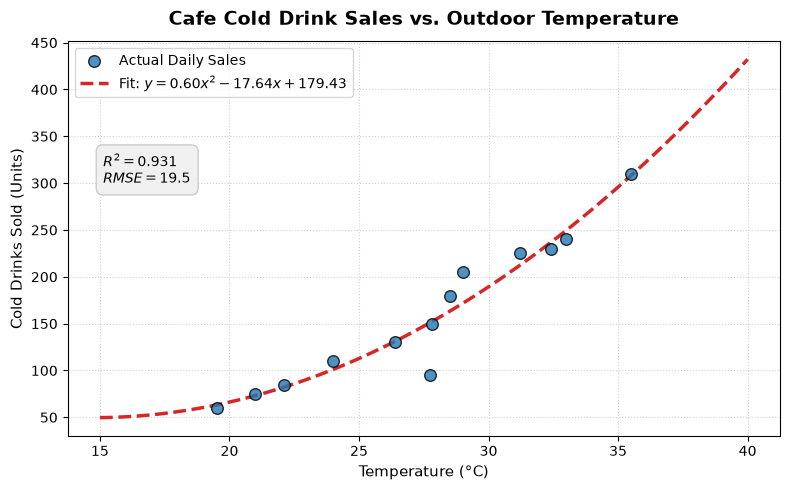

In [27]:
import matplotlib.pyplot as plt

# 1. Create canvas (Figure) and drawing area (Axes)
fig, ax = plt.subplots(figsize=(8, 5), dpi=100)

# 2. Layer 1: Scatter plot of observed data (from pandas / NumPy)
ax.scatter(
    x_temp,
    y_sales,
    color="#1f77b4",
    edgecolor="black",
    s=70,
    alpha=0.8,
    label="Actual Daily Sales",
    zorder=3,
)

# Build a clean mathematical label using the rounded values of a, b, and c
# Handles +/- signs cleanly so you don't get "+ -"
b_sign = "+" if b >= 0 else "-"
c_sign = "+" if c >= 0 else "-"
equation_label = f"Fit: $y = {a:.2f}x^2 {b_sign} {abs(b):.2f}x {c_sign} {abs(c):.2f}$"

# 3. Layer 2: Smooth quadratic regression curve with actual fitted numbers
ax.plot(
    temp_range,
    y_trendline,
    color="#d62728",
    linewidth=2.5,
    linestyle="--",
    label=equation_label,  # <-- Uses actual coefficients
    zorder=2,
)

# 4. Polish: Labels, Title, and Grid
ax.set_title(
    "Cafe Cold Drink Sales vs. Outdoor Temperature",
    fontsize=14,
    fontweight="bold",
    pad=12,
)
ax.set_xlabel("Temperature (°C)", fontsize=11)
ax.set_ylabel("Cold Drinks Sold (Units)", fontsize=11)
ax.grid(True, linestyle=":", alpha=0.6)
ax.legend(frameon=True, facecolor="white", loc="upper left")

# 5. Add a stats text box with our NumPy metrics
stats_text = f"$R^2 = {r_squared:.3f}$\n$RMSE = {rmse:.1f}$"
ax.text(
    0.05,
    0.72,
    stats_text,
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment="top",
    bbox=dict(boxstyle="round,pad=0.5", facecolor="#f0f0f0", edgecolor="#ccc"),
)

# 6. Render
plt.tight_layout()
plt.show()

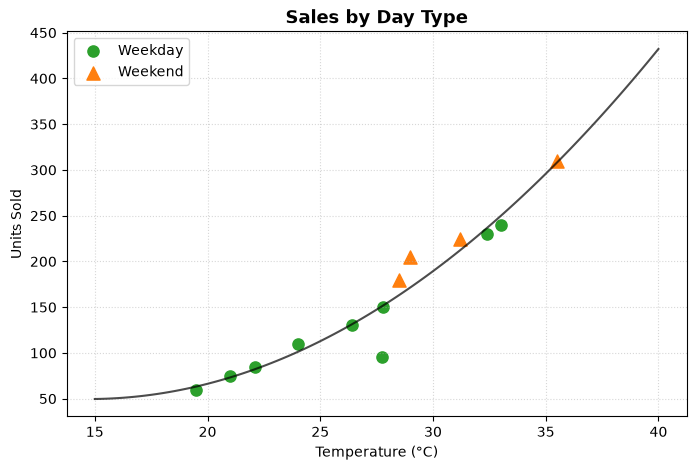

In [20]:
fig, ax = plt.subplots(figsize=(8, 5))

# Separate points based on pandas boolean column: is_weekend
weekdays = df[df["is_weekend"] == False]
weekends = df[df["is_weekend"] == True]

# Plot each subset separately with distinctive colors & markers
ax.scatter(
    weekdays["temp_c"],
    weekdays["cold_drinks_sold"],
    color="#2ca02c",
    marker="o",
    s=65,
    label="Weekday",
)

ax.scatter(
    weekends["temp_c"],
    weekends["cold_drinks_sold"],
    color="#ff7f0e",
    marker="^",
    s=90,
    label="Weekend",
)

# Overlay our existing NumPy trendline
ax.plot(temp_range, y_trendline, color="black", linewidth=1.5, alpha=0.7)

ax.set_title("Sales by Day Type", fontsize=13, fontweight="bold")
ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("Units Sold")
ax.legend()
ax.grid(True, linestyle=":", alpha=0.5)

plt.show()

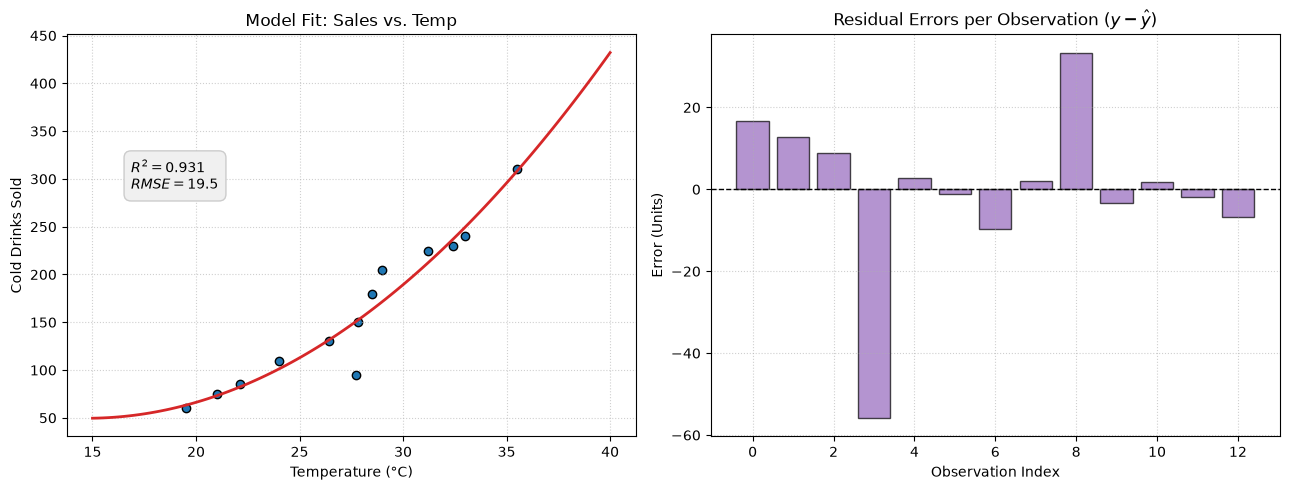

In [23]:
# Create a 1-row, 2-column figure layout
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(13, 5))

# --- PANEL 1: Regression Fit ---
ax1.scatter(x_temp, y_sales, color="#1f77b4", edgecolor="black")
ax1.plot(temp_range, y_trendline, color="#d62728", lw=2)
ax1.set_title("Model Fit: Sales vs. Temp")
ax1.set_xlabel("Temperature (°C)")
ax1.set_ylabel("Cold Drinks Sold")
ax1.grid(True, linestyle=":", alpha=0.6)

stats_text = f"$R^2 = {r_squared:.3f}$\n$RMSE = {rmse:.1f}$"
ax1.text(
    0.05,
    0.72,
    stats_text,
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment="top",
    bbox=dict(boxstyle="round,pad=0.5", facecolor="#f0f0f0", edgecolor="#ccc"),
)


# --- PANEL 2: Residual Analysis (Model Errors) ---
# A bar chart of errors: points above 0 mean underpredicted, below 0 mean overpredicted
ax2.axhline(0, color="black", linestyle="--", linewidth=1)
ax2.bar(
    range(len(residuals)),
    residuals,
    color="#9467bd",
    edgecolor="black",
    alpha=0.7,
)
ax2.set_title("Residual Errors per Observation ($y - \\hat{y}$)")
ax2.set_xlabel("Observation Index")
ax2.set_ylabel("Error (Units)")
ax2.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

In [22]:
# Save the current figure to disk
# dpi=300: Print/publication quality (dots-per-inch)
# bbox_inches='tight': Prevents axis labels from getting cut off at the border
fig.savefig("cafe_sales_analysis.png", dpi=300, bbox_inches="tight")
print("Saved chart to cafe_sales_analysis.png!")

Saved chart to cafe_sales_analysis.png!
